# SportIQ — prediction history

**This notebook grades the pick that was actually ON THE CARD**, across every market (h2h,
double chance, Over/Under goals, Over/Under corners) — not the model's 1X2 argmax.

That distinction is the whole point, and it was found the hard way. Hearts v Dundee Utd on
2026-08-09 showed **UNDER 10.5 CORNERS at 2.05** and the match finished 7-2 on corners, so the
card was **right**. The same fixture's 1X2 call was away against a 4-0 home win, so every
measurement this project had — `/history`, `/history/summary`, and this notebook — recorded it
as **wrong**. Both were true about their own object; only one is what the product promised.

The feed's headline picks run roughly 50% corners / 33% h2h / 18% double chance, so an
h2h-only accuracy describes a market that wins about a third of the cards a user ever sees.

**Card picks are recomputed, not replayed.** `best_pick` is derived per request and was never
stored, so this shows what the card shows TODAY, using today's odds. `pick_snapshots` (§7-8)
is the only true record of what was displayed at the time, and it starts 2026-08-10.


In [57]:
import asyncio
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "backend").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
BACKEND = REPO / "backend"
sys.path.insert(0, str(BACKEND))

from dotenv import load_dotenv

load_dotenv(BACKEND / ".env")

# Imported, not reimplemented. A notebook that computes its own Wilson interval will eventually
# disagree with the endpoint and there will be no way to tell which one moved.
from app.history.router import (  # noqa: E402
    ACCURACY_EDGE_THRESHOLD,
    MIN_REPORTABLE_N,
    _detectable_effect,
    _wilson_interval,
)

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
OK, BAD, NEUTRAL, ACCENT = "#2e7d32", "#c62828", "#9e9e9e", "#1565c0"

print(f"repo        : {REPO}")
print(f"reportable n: {MIN_REPORTABLE_N}   edge threshold: {ACCURACY_EDGE_THRESHOLD:.0%}")

repo        : C:\Users\User\IdeaProjects\SportIQ
reportable n: 93   edge threshold: 3%


## Query parameters

In [58]:
SPORT = None          # 'football' | 'tennis' | 'nba' | None for all
LEAGUE = None         # e.g. 'epl', 'atp'
DATE_FROM = None      # 'YYYY-MM-DD' — filters on KICKOFF, not settlement
DATE_TO = None
MARKET = None         # 'h2h' | 'double_chance' | 'goals_total' | 'corners_total' | None for all
KIND = "PRE_MATCH"    # 'PRE_MATCH' is the only population that evidences skill.
                      # 'RETRODICTION' is available for inspection; never for a headline.
                      # See the coverage section: for 578 of 740 settled fixtures the prediction
                      # the card renders was created AFTER kickoff, so grading "the card"
                      # without this filter measures hindsight, not forecasting.
INCLUDE_VOIDS = False # Voids stay out by default: most books void the bet, so scoring one as a
                      # win or a loss claims a payout the user may never have received.

# The app's own controls. None = no filtering, i.e. every card pick regardless of what a given
# user's sliders were set to. Set these to 0.6 / 1.5 to reproduce the default feed exactly.
MIN_PROBABILITY = None
MIN_ODDS = None


In [59]:
DSN = os.environ["DATABASE_URL"].replace("+asyncpg", "")

GRADED_SQL = '''
select f.id                as fixture_id,
       f.kickoff_utc,
       o.settled_at,
       s.slug              as sport,
       l.slug              as league,
       ht.name             as home_team,
       at.name             as away_team,
       p.id                as prediction_id,
       p.created_at,
       p.model_version,
       p.kind::text        as kind,
       p.home_prob, p.draw_prob, p.away_prob,
       p.confidence_tier::text as confidence_tier,
       p.feature_completeness,
       p.xg_home, p.xg_away, p.corners_xg_home, p.corners_xg_away,
       o.result::text      as result,
       o.home_score, o.away_score,
       ls.result_type::text as result_type,
       ls.home_corners, ls.away_corners
from outcomes o
join fixtures f  on f.id = o.fixture_id
join predictions p on p.fixture_id = f.id
join sports s    on s.id = f.sport_id
join leagues l   on l.id = f.league_id
join teams ht    on ht.id = f.home_team_id
join teams at    on at.id = f.away_team_id
left join fixture_live_state ls on ls.fixture_id = f.id
'''

SNAPSHOT_SQL = '''
select ps.*, f.kickoff_utc, s.slug as sport, l.slug as league,
       o.result::text as result, o.home_score, o.away_score,
       ls.result_type::text as result_type
from pick_snapshots ps
join fixtures f on f.id = ps.fixture_id
join sports s   on s.id = f.sport_id
join leagues l  on l.id = f.league_id
left join outcomes o on o.fixture_id = f.id
left join fixture_live_state ls on ls.fixture_id = f.id
'''

ODDS_SQL = '''
select o.fixture_id, o.bookmaker, o.market::text as market, o.line,
       o.home_odds, o.draw_odds, o.away_odds, o.over_odds, o.under_odds, o.updated_at
from odds o
join fixtures f on f.id = o.fixture_id
join pick_snapshots ps on ps.fixture_id = f.id
group by o.fixture_id, o.bookmaker, o.market, o.line, o.home_odds, o.draw_odds,
         o.away_odds, o.over_odds, o.under_odds, o.updated_at
'''


async def fetch(sql):
    import asyncpg

    conn = await asyncpg.connect(DSN)
    try:
        return pd.DataFrame([dict(r) for r in await conn.fetch(sql)])
    finally:
        await conn.close()


# Top-level await: ipykernel supports it, so no nest_asyncio and no extra dependency. Everything
# is pulled once into DataFrames and every section below is pure pandas — one round trip, and the
# analysis stays reproducible even if the database moves on mid-session.
raw_graded = await fetch(GRADED_SQL)
raw_snaps = await fetch(SNAPSHOT_SQL)
raw_odds = await fetch(ODDS_SQL)
print(f"loaded: {len(raw_graded)} graded rows, {len(raw_snaps)} snapshots, {len(raw_odds)} odds rows")

loaded: 831 graded rows, 59 snapshots, 5661 odds rows


In [60]:
# --- The card's pick, imported rather than reimplemented -----------------------------------
#
# _bulk_best_picks is the SAME function the feed calls, and grade_pick is a line-by-line port of
# mobile/lib/pickFormat.ts:evaluatePickCorrectness. Between them this notebook cannot report a
# pick the app would not show, or grade one differently from the badge on the card. A notebook
# carrying its own copy of either would eventually disagree and there would be no way to tell
# which had moved — the same reasoning that already applies to _wilson_interval above.
from app.core.database import async_session_factory  # noqa: E402
from app.fixtures.router import _MarketCandidate, _base_rate, _bulk_best_picks  # noqa: E402
from app.predictions.grading import grade_pick  # noqa: E402

CARD_PICK_CHUNK = 400  # keeps the IN () clause and each bulk query a sane size


async def fetch_card_picks(fixture_ids, min_probability=None):
    picks = {}
    async with async_session_factory() as db:
        for i in range(0, len(fixture_ids), CARD_PICK_CHUNK):
            best, _all = await _bulk_best_picks(
                db, list(fixture_ids[i : i + CARD_PICK_CHUNK]), min_probability=min_probability
            )
            picks.update(best)
    return picks


CARD_PICKS = await fetch_card_picks(
    raw_graded["fixture_id"].dropna().unique().tolist(), MIN_PROBABILITY
)
print(f"card picks resolved for {len(CARD_PICKS)} of "
      f"{raw_graded['fixture_id'].nunique()} settled fixtures")


card picks resolved for 721 of 740 settled fixtures


In [61]:
SELECTION_LABEL = {"1X": "1X", "X2": "X2"}


def pick_label(market, selection, line):
    """What the card prints, so a row here can be matched to a screenshot by eye."""
    if market in ("goals_total", "corners_total"):
        return f"{selection.upper()} {line:g}"
    return SELECTION_LABEL.get(selection, selection.upper())


def no_skill_baseline(market, selection, line, sport):
    """What this pick would be right at if the model said nothing.

    The old baseline was "always pick the majority result", which is meaningless once picks span
    four markets — "always pick home" says nothing about an UNDER 9.5 CORNERS card. Each market
    has its OWN measured base rate (app/fixtures/router.py:MARKET_BASE_RATES), so the honest
    generalisation is the mean base rate of the picks actually shown. Imported, not restated.

    Returns None where the sport has no measured rate — tennis abstains deliberately, since its
    "home" is a player-id tiebreak rather than a venue.
    """
    # MARKET_BASE_RATES is keyed on line=None for h2h and double chance, but pandas turns a
    # column of None into NaN, and ("double_chance", "1X", nan) matches nothing. That silently
    # reported baseline_cov 0.0 for every double-chance pick on the first run.
    line = None if line is None or pd.isna(line) else float(line)
    return _base_rate(
        _MarketCandidate(
            selection=selection, probability=None, odds=None,
            market=market, line=line, feature_completeness=None,
        ),
        sport,
    )


DEDUP_REPORT = {}


def dedup(df):
    """One row per (fixture, kind) — the final forecast, not every revision of it.

    run_predictions APPENDS a prediction rather than replacing one, so a fixture re-predicted as
    its features changed carries a series. Consuming that series as though each row were an
    independent event weights a fixture by how often it happened to be re-predicted. Measured
    2026-08-13: 143 settled football pre-match rows sat on 63 fixtures, one carrying 25, and the
    accuracy moved 0.5524 -> 0.3651 once each fixture counted once.

    Prefer a row created BEFORE kickoff, then the latest of those. created_at alone is not
    enough — regeneration reset it on 91 football rows to after their own kickoffs. Identical
    ordering to app/history/router.py:_representative_prediction_ids.

    NOTE the residual mismatch, which is real and deliberate: _bulk_best_picks builds the card
    from the LATEST prediction by created_at regardless of kind, while this prefers the last
    pre-kickoff one. They coincide exactly on the KIND='PRE_MATCH' population this notebook
    reports, which is why that filter is the default rather than a nicety."""
    before = df.copy()
    before["_pre"] = (before["created_at"] < before["kickoff_utc"]).astype(int)
    kept = (
        before.sort_values(["_pre", "created_at", "prediction_id"], ascending=[False, False, False])
        .groupby(["fixture_id", "kind"], as_index=False)
        .head(1)
        .drop(columns="_pre")
    )
    DEDUP_REPORT.update(rows_in=len(df), fixtures_out=len(kept), collapsed=len(df) - len(kept))
    return kept


def prepare(df):
    df = df.copy()
    df["kickoff_utc"] = pd.to_datetime(df["kickoff_utc"], utc=True)
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
    df = dedup(df)
    df["day"] = df["kickoff_utc"].dt.date

    # .map(dict) yields NaN — a float — for a fixture with no card pick, so every accessor
    # needs a real presence test rather than `is not None`.
    picks = [CARD_PICKS.get(fid) for fid in df["fixture_id"]]

    def field(name):
        return [getattr(p, name, None) for p in picks]

    df["has_card_pick"] = [p is not None for p in picks]
    df["market"] = field("market")
    df["selection"] = field("selection")
    df["line"] = field("line")
    df["predicted_prob"] = field("probability")
    df["odds"] = field("odds")
    df["pick_completeness"] = field("feature_completeness")
    df["predicted"] = df.apply(
        lambda r: pick_label(r.market, r.selection, r.line) if r.has_card_pick else None, axis=1
    )
    # None means UNVERIFIABLE and is never counted as a loss — corners are null for NBA and for
    # anything settled before fixture_live_state gained its corner columns.
    df["graded"] = df.apply(
        lambda r: grade_pick(
            r.market, r.selection, r.line, r.home_score, r.away_score,
            r.home_corners, r.away_corners, r.result_type,
        ) if r.has_card_pick else None,
        axis=1,
    )
    df["baseline_rate"] = df.apply(
        lambda r: no_skill_baseline(r.market, r.selection, r.line, r.sport)
        if r.has_card_pick else None,
        axis=1,
    )
    return df


def gradeable(df):
    """Rows that HAD a card pick and whose pick can be graded, with an int `correct` column.

    Kept as one helper because two places need it and a second inline copy would eventually
    disagree about what counts as gradeable. A pick with no verdict (corners with no real count)
    is dropped rather than scored as a loss.
    """
    out = df[df["has_card_pick"] & df["graded"].notna()].copy()
    out["correct"] = out["graded"].astype(int)
    return out


def apply_filters(df):
    out = df
    if SPORT:
        out = out[out["sport"] == SPORT]
    if LEAGUE:
        out = out[out["league"] == LEAGUE]
    if MARKET:
        out = out[out["market"] == MARKET]
    if DATE_FROM:
        out = out[out["day"] >= pd.Timestamp(DATE_FROM).date()]
    if DATE_TO:
        out = out[out["day"] <= pd.Timestamp(DATE_TO).date()]
    if MIN_ODDS is not None:
        out = out[out["odds"].notna() & (out["odds"] >= MIN_ODDS)]
    return out


all_graded = prepare(raw_graded)
excluded_void = int(all_graded["result_type"].notna().sum())
no_card = int((~all_graded["has_card_pick"]).sum())
population = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
by_kind = population["kind"].value_counts().to_dict()

carded = apply_filters(population[population["kind"] == KIND])
carded = carded[carded["has_card_pick"]]
ungradable = int(carded["graded"].isna().sum())
graded = gradeable(carded)

print(f"collapsed {DEDUP_REPORT['collapsed']} duplicate prediction rows "
      f"({DEDUP_REPORT['rows_in']} rows -> {DEDUP_REPORT['fixtures_out']} fixture/kind pairs)")
print(f"kind breakdown (all sports)   : {by_kind}")
print(f"settled, but NO card pick     : {no_card}  (guards removed it, or no prediction)")
print(f"excluded as VOID              : {excluded_void}")
print(f"card picks after filters      : {len(carded)}, kind={KIND}")
print(f"  of those, ungradable        : {ungradable}  (corners with no real count — never a loss)")
print(f"  graded                      : {len(graded)}")


collapsed 91 duplicate prediction rows (831 rows -> 740 fixture/kind pairs)
kind breakdown (all sports)   : {'UNKNOWN': 582, 'PRE_MATCH': 148}
settled, but NO card pick     : 19  (guards removed it, or no prediction)
excluded as VOID              : 10
card picks after filters      : 147, kind=PRE_MATCH
  of those, ungradable        : 0  (corners with no real count — never a loss)
  graded                      : 147


## 1. Coverage — what can honestly be said at all

**Every accuracy below grades the pick that was on the card**, across all four markets, using
the feed's own selection function and the phone's own grading rule.

**One prediction per fixture.** `run_predictions` appends a row rather than replacing one, so a
fixture re-predicted as its features changed carries a whole series — up to 25 rows for a single
football fixture. Counting those as independent events weights a fixture by how often it happened
to be re-predicted, which moved the reported football accuracy from **0.5524 to 0.3651**.

**Baseline is the mean of each pick's OWN market base rate**, not "always pick home" — that
question is meaningless for an UNDER 9.5 CORNERS card. Tennis has no measured rates by design
(its "home" is a player-id tiebreak, not a venue), so its baseline is blank rather than borrowed.

`n`, the 95% Wilson interval and the **minimum detectable effect** are printed together
deliberately. A sample whose detectable effect exceeds the edge we believe in cannot confirm
*or* refute that edge, and that is a different statement from "not enough rows to print".


In [62]:
def summarise(df, label):
    n = len(df)
    if n == 0:
        return {"population": label, "n": 0}
    correct = int(df["correct"].sum())
    acc = correct / n
    lo, hi = _wilson_interval(correct, n)
    mde = _detectable_effect(acc, n)
    # The no-skill alternative for a MIXED-MARKET population: the mean of each pick's own
    # measured base rate. "Always pick the majority result" cannot be asked of a corners card.
    # The gap is computed on the SUBSET that has a base rate, never by comparing a full-sample
    # accuracy against a baseline drawn from part of it. On the first run that produced a
    # headline "+14.8pp" where the accuracy spanned 147 picks and the baseline spanned 19.
    comparable = df[df["baseline_rate"].notna()]
    baseline = comparable["baseline_rate"].mean() if len(comparable) else None
    comparable_acc = comparable["correct"].mean() if len(comparable) else None
    return {
        "population": label,
        "n": n,
        "accuracy": round(acc, 4),
        "ci_low": round(lo, 4),
        "ci_high": round(hi, 4),
        "baseline_n": len(comparable),
        "baseline": round(baseline, 4) if baseline is not None else None,
        "acc_on_baseline_n": round(comparable_acc, 4) if comparable_acc is not None else None,
        "gap_pp": (round((comparable_acc - baseline) * 100, 2)
                   if baseline is not None else None),
        "detectable_pp": round(mde * 100, 2),
        "reportable": n >= MIN_REPORTABLE_N,
        "conclusive": mde <= ACCURACY_EDGE_THRESHOLD,
    }


rows = [summarise(graded, "ALL (filtered)")]
rows += [summarise(g, f"sport={s}") for s, g in graded.groupby("sport")]
coverage = pd.DataFrame(rows)
display(coverage)

print("MARKET MIX of the graded card picks - this is what the product actually shows:")
if not graded.empty:
    mix = graded["market"].value_counts(normalize=True).mul(100).round(1)
    for market, pct in mix.items():
        n_market = int((graded["market"] == market).sum())
        print(f"  {market:16} {pct:5.1f}%  (n={n_market})")
    print()
    print("An h2h-only accuracy - which is all this project measured until now - describes "
          f"{mix.get('h2h', 0):.0f}% of these cards.")

if graded["sport"].nunique() > 1:
    print()
    print("NOTE: the ALL row pools sports AND markets. Its n is real; read the per-sport and "
          "per-market rows for anything comparative.")

unreportable = coverage[(coverage["n"] > 0) & (~coverage["reportable"])]["population"].tolist()
inconclusive = coverage[(coverage["n"] > 0) & (~coverage["conclusive"])]["population"].tolist()
print()
print(f"below the reportable floor (n<{MIN_REPORTABLE_N}): {unreportable or 'none'}")
print(f"cannot settle a {ACCURACY_EDGE_THRESHOLD:.0%} edge either way : {inconclusive or 'none'}")
print()
print(f"UNKNOWN-provenance rows excluded from every metric above: {by_kind.get('UNKNOWN', 0)} "
      "(counted, not hidden). For 578 of 740 settled fixtures the prediction the card renders "
      "was created AFTER kickoff; grading those would measure hindsight, so KIND filters them "
      "out.")


,population,n,accuracy,ci_low,ci_high,baseline_n,baseline,acc_on_baseline_n,gap_pp,detectable_pp,reportable,conclusive
0,ALL (filtered),147,0.6939,0.6152,0.7627,62,0.6391,0.7258,8.67,9.45,True,False
1,sport=football,62,0.7258,0.6041,0.8212,62,0.6391,0.7258,8.67,14.09,False,False
2,sport=tennis,85,0.6706,0.5652,0.7612,0,NaN,NaN,NaN,12.68,False,False


MARKET MIX of the graded card picks - this is what the product actually shows:
  h2h               57.8%  (n=85)
  double_chance     29.3%  (n=43)
  corners_total     12.9%  (n=19)

An h2h-only accuracy - which is all this project measured until now - describes 58% of these cards.

NOTE: the ALL row pools sports AND markets. Its n is real; read the per-sport and per-market rows for anything comparative.

below the reportable floor (n<93): ['sport=football', 'sport=tennis']
cannot settle a 3% edge either way : ['ALL (filtered)', 'sport=football', 'sport=tennis']

UNKNOWN-provenance rows excluded from every metric above: 582 (counted, not hidden). For 578 of 740 settled fixtures the prediction the card renders was created AFTER kickoff; grading those would measure hindsight, so KIND filters them out.


## 2. Daily results

The chart the day-to-day question asks for — but read the second panel with the error bars in
mind. At roughly ten settled fixtures a day, a single day's accuracy has a confidence interval
tens of points wide, so day-to-day movement is overwhelmingly noise. The bars show volume, which
is real; the points show accuracy, whose uncertainty is drawn rather than left implied.

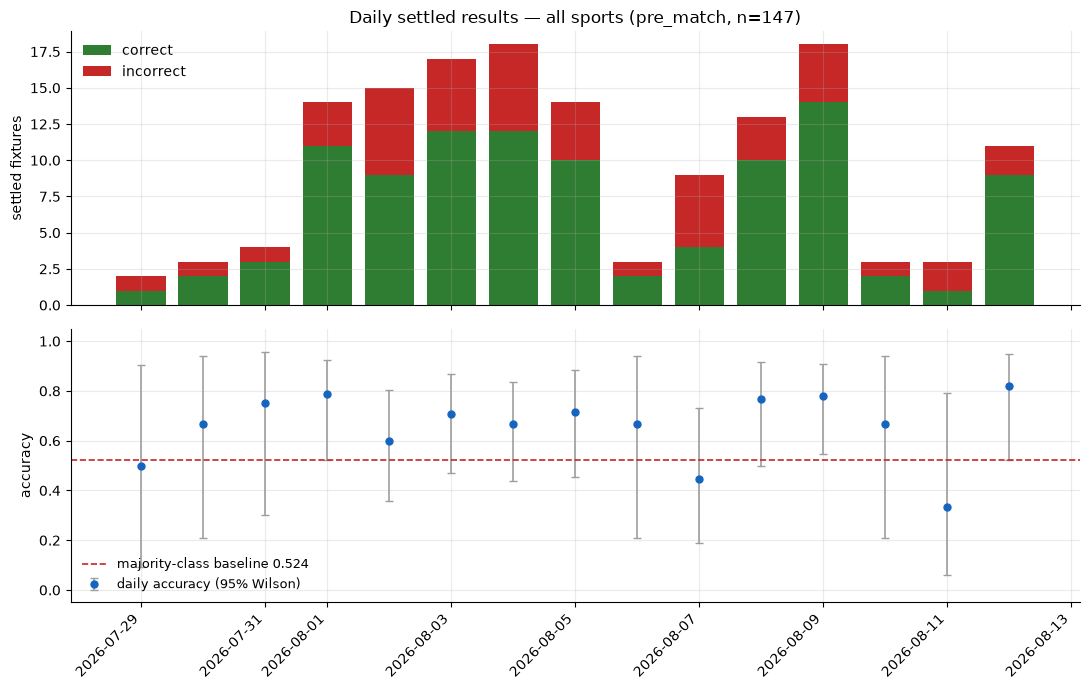

,day,n,correct,accuracy,ci
0,2026-07-29,2,1,0.500000,"[0.09, 0.91]"
1,2026-07-30,3,2,0.666667,"[0.21, 0.94]"
2,2026-07-31,4,3,0.750000,"[0.30, 0.95]"
3,2026-08-01,14,11,0.785714,"[0.52, 0.92]"
4,2026-08-02,15,9,0.600000,"[0.36, 0.80]"
5,2026-08-03,17,12,0.705882,"[0.47, 0.87]"
6,2026-08-04,18,12,0.666667,"[0.44, 0.84]"
7,2026-08-05,14,10,0.714286,"[0.45, 0.88]"
8,2026-08-06,3,2,0.666667,"[0.21, 0.94]"
9,2026-08-07,9,4,0.444444,"[0.19, 0.73]"


In [63]:
def daily_frame(df):
    g = df.groupby("day").agg(n=("correct", "size"), correct=("correct", "sum")).reset_index()
    g["accuracy"] = g["correct"] / g["n"]
    ci = g.apply(lambda r: _wilson_interval(int(r.correct), int(r.n)), axis=1)
    g["ci_low"] = [c[0] for c in ci]
    g["ci_high"] = [c[1] for c in ci]
    return g


if graded.empty:
    print("no rows for the current filters")
else:
    d = daily_frame(graded)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    ax1.bar(d["day"], d["correct"], color=OK, label="correct")
    ax1.bar(d["day"], d["n"] - d["correct"], bottom=d["correct"], color=BAD, label="incorrect")
    ax1.set_ylabel("settled fixtures")
    ax1.set_title(f"Daily settled results — {SPORT or 'all sports'} ({KIND.lower()}, n={len(graded)})")
    ax1.legend(loc="upper left", frameon=False)

    base = graded["result"].value_counts(normalize=True).max()
    ax2.errorbar(
        d["day"], d["accuracy"],
        yerr=[d["accuracy"] - d["ci_low"], d["ci_high"] - d["accuracy"]],
        fmt="o", color=ACCENT, ecolor=NEUTRAL, elinewidth=1.2, capsize=3, markersize=5,
        label="daily accuracy (95% Wilson)",
    )
    ax2.axhline(base, color=BAD, ls="--", lw=1.2, label=f"majority-class baseline {base:.3f}")
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("accuracy")
    ax2.legend(loc="lower left", frameon=False, fontsize=9)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(d.assign(**{"ci": d.apply(lambda r: f"[{r.ci_low:.2f}, {r.ci_high:.2f}]", axis=1)})
             [["day", "n", "correct", "accuracy", "ci"]])

### Cumulative accuracy — the same data, read the way it should be

Daily points are noise; the running total is where a real edge would eventually show. The ribbon
is the 95% Wilson interval, which narrows only as `n` grows. **An edge is demonstrated when the
ribbon's lower bound clears the baseline and stays there** — not when a point does.

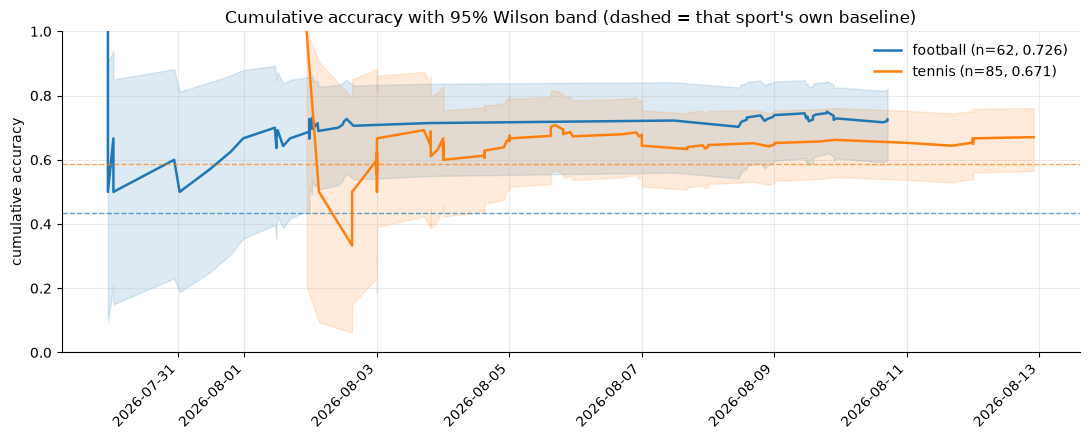

In [64]:
if graded.empty:
    print("no rows for the current filters")
else:
    fig, ax = plt.subplots()
    for sport, g in graded.sort_values("kickoff_utc").groupby("sport"):
        run_n = np.arange(1, len(g) + 1)
        run_correct = g["correct"].cumsum().to_numpy()
        acc = run_correct / run_n
        ci = [_wilson_interval(int(c), int(n)) for c, n in zip(run_correct, run_n)]
        lo, hi = np.array([c[0] for c in ci]), np.array([c[1] for c in ci])
        days = g["kickoff_utc"].to_numpy()
        line, = ax.plot(days, acc, lw=1.8, label=f"{sport} (n={len(g)}, {acc[-1]:.3f})")
        ax.fill_between(days, lo, hi, alpha=0.15, color=line.get_color())
        base = g["result"].value_counts(normalize=True).max()
        ax.axhline(base, ls="--", lw=1, color=line.get_color(), alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_ylabel("cumulative accuracy")
    ax.set_title("Cumulative accuracy with 95% Wilson band (dashed = that sport's own baseline)")
    ax.legend(frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 3. Calibration — is a stated 70% actually 70%?

Accuracy only asks whether the top pick landed. Calibration asks whether the *number* is
trustworthy, which is what a user stakes money against.

Buckets under 20 samples are suppressed rather than plotted: at that size a bucket rate is noise
and drawing it invites reading a wobble as miscalibration.

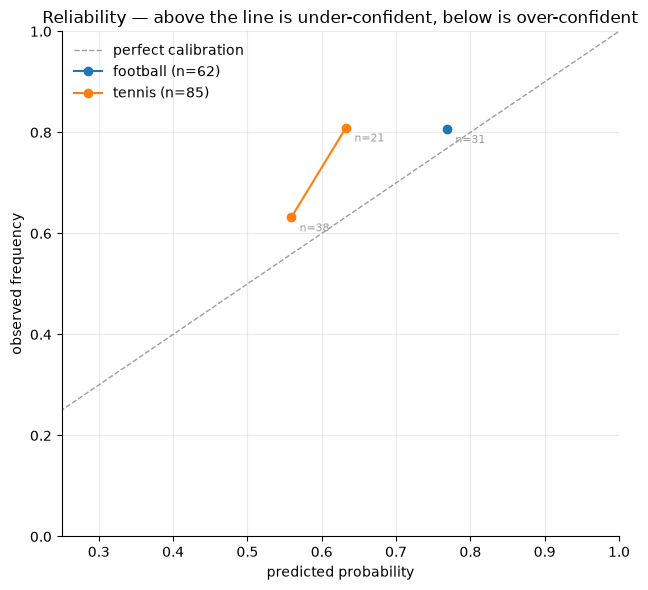


football


,bucket,mid,n,predicted,observed
0,0.7-0.8,0.75,31,0.769,0.806



tennis


,bucket,mid,n,predicted,observed
0,0.5-0.6,0.55,38,0.559,0.632
1,0.6-0.7,0.65,21,0.633,0.810


In [65]:
MIN_BUCKET = 20


def reliability(df, edges=np.arange(0.3, 1.01, 0.1)):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = df[(df["predicted_prob"] >= lo) & (df["predicted_prob"] < hi)]
        if len(sel) >= MIN_BUCKET:
            out.append({
                "bucket": f"{lo:.1f}-{hi:.1f}",
                "mid": (lo + hi) / 2,
                "n": len(sel),
                "predicted": sel["predicted_prob"].mean(),
                "observed": sel["correct"].mean(),
            })
    return pd.DataFrame(out)


if graded.empty:
    print("no rows")
else:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], ls="--", color=NEUTRAL, lw=1, label="perfect calibration")
    any_plotted = False
    for sport, g in graded.groupby("sport"):
        rel = reliability(g)
        if rel.empty:
            print(f"{sport}: every bucket under {MIN_BUCKET} samples — suppressed as noise")
            continue
        any_plotted = True
        ax.plot(rel["predicted"], rel["observed"], "o-", label=f"{sport} (n={len(g)})")
        for _, r in rel.iterrows():
            ax.annotate(f"n={r.n:.0f}", (r["predicted"], r["observed"]),
                        textcoords="offset points", xytext=(6, -10), fontsize=8, color=NEUTRAL)
    ax.set_xlabel("predicted probability")
    ax.set_ylabel("observed frequency")
    ax.set_title("Reliability — above the line is under-confident, below is over-confident")
    ax.set_xlim(0.25, 1.0)
    ax.set_ylim(0, 1.0)
    if any_plotted:
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    for sport, g in graded.groupby("sport"):
        rel = reliability(g)
        if not rel.empty:
            print(f"\n{sport}")
            display(rel.round(3))

In [66]:
# Brier over the model's own top pick. Lower is better; it rewards being right AND being
# appropriately unsure, which plain accuracy cannot distinguish.
if not graded.empty:
    brier = (
        graded.assign(sq=(graded["predicted_prob"] - graded["correct"]) ** 2)
        .groupby("sport")
        .agg(n=("sq", "size"), brier=("sq", "mean"),
             mean_predicted=("predicted_prob", "mean"), observed=("correct", "mean"))
        .round(4)
    )
    brier["overconfidence"] = (brier["mean_predicted"] - brier["observed"]).round(4)
    display(brier)
    print("overconfidence > 0 means the model claims more than it delivers, on average")

,n,brier,mean_predicted,observed,overconfidence
sport,,,,,
football,62,0.1869,0.7726,0.7258,0.0468
tennis,85,0.2425,0.6319,0.6706,-0.0387


overconfidence > 0 means the model claims more than it delivers, on average


## 4. The confidence badge

The badge is the most prominent number in the product, and the least examined. It was set from
provisional thresholds that were never validated — so this panel exists to check whether HIGH
actually beats MEDIUM.

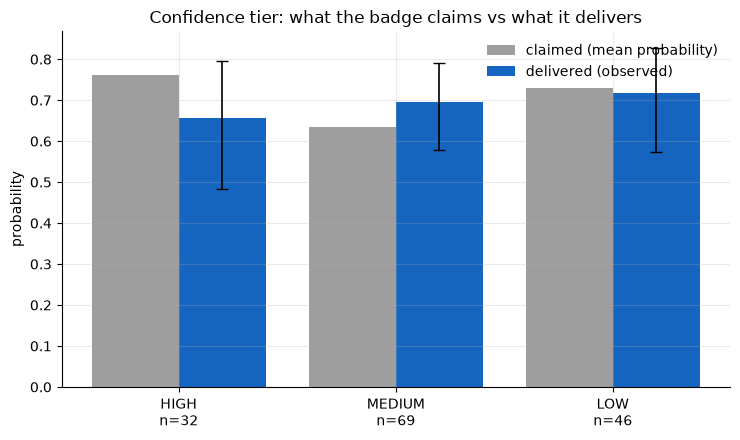

,n,claimed,delivered,ci_low,ci_high
confidence_tier,,,,,
HIGH,32,0.7606,0.6562,0.4831,0.7959
MEDIUM,69,0.6338,0.6957,0.5792,0.7915
LOW,46,0.7291,0.7174,0.5745,0.8268



HIGH (0.656) is delivering BELOW MEDIUM (0.696).
Check the intervals before calling the ordering inverted — if they overlap,
the ordering is unestablished rather than reversed.


In [67]:
if not graded.empty and graded["confidence_tier"].notna().any():
    tier = (
        graded.groupby("confidence_tier")
        .agg(n=("correct", "size"), claimed=("predicted_prob", "mean"),
             delivered=("correct", "mean"))
        .reindex(["HIGH", "MEDIUM", "LOW"]).dropna(how="all")
    )
    ci = [_wilson_interval(int(round(r.delivered * r.n)), int(r.n)) for _, r in tier.iterrows()]
    tier["ci_low"] = [c[0] for c in ci]
    tier["ci_high"] = [c[1] for c in ci]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = np.arange(len(tier))
    ax.bar(x - 0.2, tier["claimed"], width=0.4, color=NEUTRAL, label="claimed (mean probability)")
    ax.bar(x + 0.2, tier["delivered"], width=0.4, color=ACCENT, label="delivered (observed)")
    ax.errorbar(x + 0.2, tier["delivered"],
                yerr=[tier["delivered"] - tier["ci_low"], tier["ci_high"] - tier["delivered"]],
                fmt="none", ecolor="black", capsize=4, elinewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\nn={int(r.n)}" for i, r in tier.iterrows()])
    ax.set_ylabel("probability")
    ax.set_title("Confidence tier: what the badge claims vs what it delivers")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    display(tier.round(4))
    if {"HIGH", "MEDIUM"}.issubset(tier.index):
        h, m = tier.loc["HIGH"], tier.loc["MEDIUM"]
        if h["delivered"] < m["delivered"]:
            print(f"\nHIGH ({h.delivered:.3f}) is delivering BELOW MEDIUM ({m.delivered:.3f}).")
            print("Check the intervals before calling the ordering inverted — if they overlap,")
            print("the ordering is unestablished rather than reversed.")
else:
    print("no confidence tiers in the current population")

## 5. Feature completeness

The fraction of the model's own feature vector that had a real value at inference time. A
prediction built from a mostly-empty vector is not wrong, but it carries far less information —
and the feed used to render both with identical authority. `MIN_FEATURE_COMPLETENESS = 0.25` is
the hard floor in `app/fixtures/router.py`; mobile dims a badge below 0.35.

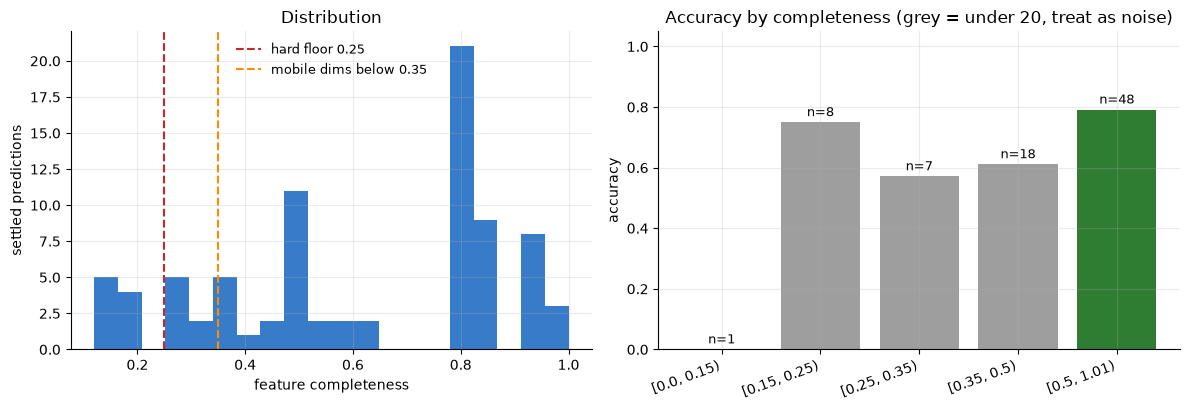

,band,n,accuracy,mean_prob
0,"[0.0, 0.15)",1,0.000,0.646
1,"[0.15, 0.25)",8,0.750,0.689
2,"[0.25, 0.35)",7,0.571,0.689
3,"[0.35, 0.5)",18,0.611,0.805
4,"[0.5, 1.01)",48,0.792,0.669


In [68]:
FLOOR_HARD, FLOOR_DIM = 0.25, 0.35

fc = graded[graded["feature_completeness"].notna()]
if fc.empty:
    print("no feature_completeness recorded in this population (the column is not backfilled — "
          "older predictions genuinely have no measurement)")
else:
    bins = [0, 0.15, 0.25, 0.35, 0.5, 1.01]
    fc = fc.assign(band=pd.cut(fc["feature_completeness"], bins=bins, right=False))
    band = fc.groupby("band", observed=True).agg(
        n=("correct", "size"), accuracy=("correct", "mean"),
        mean_prob=("predicted_prob", "mean")).reset_index()
    band["band"] = band["band"].astype(str)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
    ax1.hist(fc["feature_completeness"], bins=20, color=ACCENT, alpha=0.85)
    ax1.axvline(FLOOR_HARD, color=BAD, ls="--", label=f"hard floor {FLOOR_HARD}")
    ax1.axvline(FLOOR_DIM, color="darkorange", ls="--", label=f"mobile dims below {FLOOR_DIM}")
    ax1.set_xlabel("feature completeness")
    ax1.set_ylabel("settled predictions")
    ax1.set_title("Distribution")
    ax1.legend(frameon=False, fontsize=9)

    ax2.bar(band["band"], band["accuracy"], color=[NEUTRAL if n < MIN_BUCKET else OK
                                                   for n in band["n"]])
    for i, r in band.iterrows():
        ax2.text(i, r["accuracy"] + 0.02, f"n={int(r.n)}", ha="center", fontsize=9)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("accuracy")
    ax2.set_title(f"Accuracy by completeness (grey = under {MIN_BUCKET}, treat as noise)")
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    display(band.round(3))

## 6. Per league, against each league's own baseline

A pooled number can be carried by one league. Each league is scored against the mean base rate
of **its own** card picks, so a league whose feed leans on corners is not compared against a
football-wide h2h rate.


,league,n,accuracy,ci_low,ci_high,baseline_n,baseline,acc_on_baseline_n,gap_pp,detectable_pp,reportable,conclusive
1,atp,85,0.6706,0.5652,0.7612,0,NaN,NaN,NaN,12.68,False,False
2,brasileirao,16,0.6875,0.4440,0.8584,16,0.6484,0.6875,3.91,28.82,False,False
5,mls,16,0.6875,0.4440,0.8584,16,0.6272,0.6875,6.03,28.82,False,False
3,csl,15,0.8000,0.5481,0.9295,15,0.6932,0.8000,10.68,25.69,False,False
6,scottish_prem,12,0.7500,0.4677,0.9111,12,0.5962,0.7500,15.38,31.09,False,False
0,allsvenskan,2,1.0000,0.3424,1.0000,2,0.5455,1.0000,45.45,0.01,False,True
4,liga_i,1,0.0000,0.0000,0.7935,1,0.5703,0.0000,-57.03,0.01,False,True


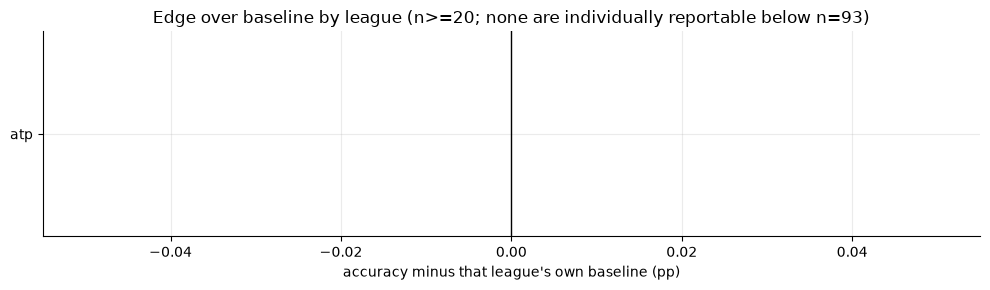

Every per-league cut here is far below the reportable floor. Treat the ordering as a prompt for a question, never as a finding — an earlier per-league table read from live data had two leagues at +26pp and -27pp whose signs both FLIPPED on a proper test set.


In [69]:
if graded.empty:
    print("no rows")
else:
    per_league = (
        pd.DataFrame([summarise(g, lg) for lg, g in graded.groupby("league")])
        .rename(columns={"population": "league"})
        .sort_values("n", ascending=False)
    )
    display(per_league)

    show = per_league[per_league["n"] >= MIN_BUCKET]
    if not show.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * len(show))))
        colors = [OK if g > 0 else BAD for g in show["gap_pp"]]
        ax.barh(show["league"], show["gap_pp"], color=colors, alpha=0.85)
        ax.axvline(0, color="black", lw=1)
        ax.set_xlabel("accuracy minus that league's own baseline (pp)")
        ax.set_title(f"Edge over baseline by league (n>={MIN_BUCKET}; none are individually reportable "
                     f"below n={MIN_REPORTABLE_N})")
        for i, (_, r) in enumerate(show.iterrows()):
            ax.text(r["gap_pp"], i, f"  n={int(r.n)}", va="center", fontsize=8)
        plt.tight_layout()
        plt.show()
    print("Every per-league cut here is far below the reportable floor. Treat the ordering as a "
          "prompt for a question, never as a finding — an earlier per-league table read from live "
          "data had two leagues at +26pp and -27pp whose signs both FLIPPED on a proper test set.")

## 6b. Per market — the cut that was impossible before

Until the card's pick became the graded object, every accuracy in this project was h2h. This is
the first view of whether the markets the feed actually leans on are any good, each against its
own measured base rate.


,market,n,accuracy,ci_low,ci_high,baseline_n,baseline,acc_on_baseline_n,gap_pp,detectable_pp,reportable,conclusive
2,h2h,85,0.6706,0.5652,0.7612,0,NaN,NaN,NaN,12.68,False,False
1,double_chance,43,0.7209,0.5731,0.8325,43,0.6804,0.7209,4.05,17.01,False,False
0,corners_total,19,0.7368,0.5121,0.8819,19,0.5455,0.7368,19.14,25.12,False,False


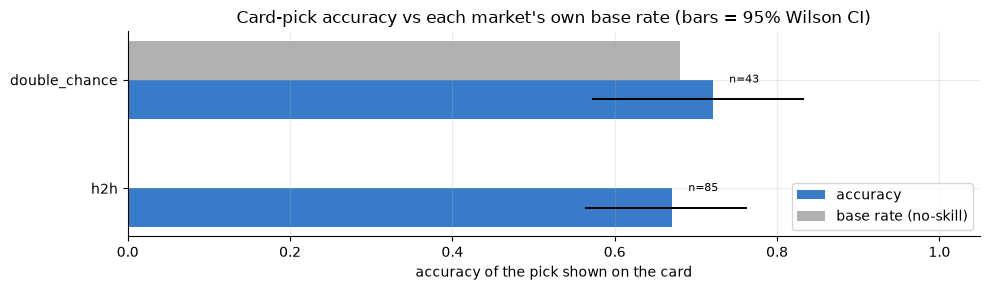

Read the INTERVALS, not the bars. A market beating its base rate on n=30 has an interval wide enough to contain the base rate comfortably. corners_total is the one to watch: it wins roughly half the headline picks and is the only derived market with a measured correlation to reality (r=+0.288, n=234).


In [70]:
if graded.empty:
    print("no rows")
else:
    per_market = (
        pd.DataFrame([summarise(g, m) for m, g in graded.groupby("market")])
        .rename(columns={"population": "market"})
        .sort_values("n", ascending=False)
    )
    display(per_market)

    show = per_market[per_market["n"] >= MIN_BUCKET]
    if not show.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(show))))
        y = np.arange(len(show))
        ax.barh(y - 0.18, show["accuracy"], height=0.36, color=ACCENT, alpha=0.85, label="accuracy")
        ax.barh(y + 0.18, show["baseline"].fillna(0), height=0.36, color=NEUTRAL, alpha=0.8,
                label="base rate (no-skill)")
        for i, (_, r) in enumerate(show.iterrows()):
            lo, hi = r["ci_low"], r["ci_high"]
            ax.plot([lo, hi], [i - 0.18, i - 0.18], color="black", lw=1.4)
            ax.text(max(r["accuracy"], r["baseline"] or 0) + 0.02, i, f"n={int(r.n)}",
                    va="center", fontsize=8)
        ax.set_yticks(y)
        ax.set_yticklabels(show["market"])
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("accuracy of the pick shown on the card")
        ax.set_title("Card-pick accuracy vs each market's own base rate (bars = 95% Wilson CI)")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    print("Read the INTERVALS, not the bars. A market beating its base rate on n=30 has an "
          "interval wide enough to contain the base rate comfortably. corners_total is the one "
          "to watch: it wins roughly half the headline picks and is the only derived market "
          "with a measured correlation to reality (r=+0.288, n=234).")


## 7. Closing line value — product skill, and only from 2026-08-10

CLV is `taken / closing - 1`: did the price we showed beat where the market finished? It is the
one measure that separates a model with an edge from one that merely backs short favourites.

Two things bound it. Snapshots start on 2026-08-10, so nothing before that can be measured at all.
And the **control matters**: some drift is systematic rather than anything about the model, so the
side we did *not* favour is measured alongside. The control is not clean — for a 3-way market it
is usually the longer, more volatile price — so read the gap directionally, not precisely.

,n,mean_clv,median_clv
sport,,,
tennis,5,-0.2836,-0.34


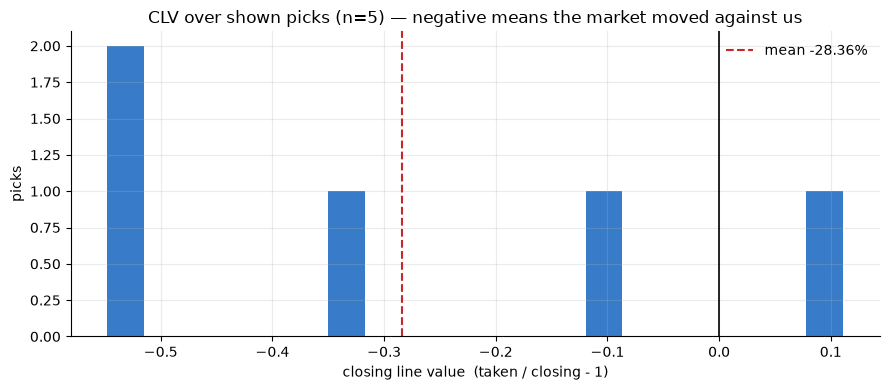

n=5. Far too few to conclude anything; this panel exists so the number accumulates in the open rather than being computed once, later, from memory.


In [71]:
SELECTION_COLUMN = {
    ("h2h", "home"): "home_odds", ("h2h", "draw"): "draw_odds", ("h2h", "away"): "away_odds",
    ("double_chance", "home_or_draw"): "home_odds",
    ("double_chance", "away_or_draw"): "away_odds",
    ("goals_total", "over"): "over_odds", ("goals_total", "under"): "under_odds",
    ("corners_total", "over"): "over_odds", ("corners_total", "under"): "under_odds",
}
MARKET_ENUM = {"h2h": "H2H", "double_chance": "DOUBLE_CHANCE",
               "goals_total": "GOALS_TOTAL", "corners_total": "CORNERS_TOTAL"}

if raw_snaps.empty:
    print("no pick snapshots yet")
else:
    snaps = raw_snaps.copy()
    snaps["kickoff_utc"] = pd.to_datetime(snaps["kickoff_utc"], utc=True)
    snaps["captured_at"] = pd.to_datetime(snaps["captured_at"], utc=True)
    odds = raw_odds.copy()
    odds["updated_at"] = pd.to_datetime(odds["updated_at"], utc=True)

    def closing_price(snap, selection):
        col = SELECTION_COLUMN.get((snap["market"], selection))
        if col is None:
            return None
        cand = odds[(odds["fixture_id"] == snap["fixture_id"])
                    & (odds["market"] == MARKET_ENUM.get(snap["market"]))
                    & (odds["updated_at"] <= snap["kickoff_utc"])]
        if pd.notna(snap.get("line")):
            cand = cand[cand["line"] == snap["line"]]
        cand = cand[cand[col].notna()]
        if cand.empty:
            return None
        # The LAST price before kickoff, per book, then the best of them — matching how the feed
        # picks a price. Taking a mean across books would invent a line no user could have taken.
        latest = cand.sort_values("updated_at").groupby("bookmaker").tail(1)
        return float(latest[col].max())

    OPPOSITE = {"home": "away", "away": "home", "over": "under", "under": "over",
                "home_or_draw": "away_or_draw", "away_or_draw": "home_or_draw"}

    rows = []
    for _, s in snaps.iterrows():
        if pd.isna(s["odds"]) or pd.isna(s["result"]):
            continue
        close = closing_price(s, s["selection"])
        ctrl_sel = OPPOSITE.get(s["selection"])
        ctrl_taken = closing_price(s, ctrl_sel) if ctrl_sel else None
        if close and close > 0:
            rows.append({
                "sport": s["sport"], "market": s["market"], "selection": s["selection"],
                "taken": s["odds"], "closing": close,
                "clv": s["odds"] / close - 1,
                "captured_at": s["captured_at"],
            })
    clv = pd.DataFrame(rows)
    if clv.empty:
        print(f"{len(snaps)} snapshots, but none could be matched to a closing price yet — the "
              "closing-odds capture only fires 10-45 minutes before kickoff.")
    else:
        display(clv.groupby("sport").agg(n=("clv", "size"), mean_clv=("clv", "mean"),
                                         median_clv=("clv", "median")).round(4))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(clv["clv"], bins=20, color=ACCENT, alpha=0.85)
        ax.axvline(0, color="black", lw=1.2)
        ax.axvline(clv["clv"].mean(), color=BAD, ls="--",
                   label=f"mean {clv['clv'].mean():+.2%}")
        ax.set_xlabel("closing line value  (taken / closing - 1)")
        ax.set_ylabel("picks")
        ax.set_title(f"CLV over shown picks (n={len(clv)}) — negative means the market moved against us")
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()
        print(f"n={len(clv)}. Far too few to conclude anything; this panel exists so the number "
              "accumulates in the open rather than being computed once, later, from memory.")

## 8. What the feed actually showed

Market mix is worth watching for its own sake. The complaint that started this line of work was
"every card shows UNDER 3.5" — single-market concentration. `goals_total` is now barred from the
headline pick for having no demonstrated signal, which pushed corners to roughly half of all
picks. That is the same shape of concentration, with a market that at least has measured signal.

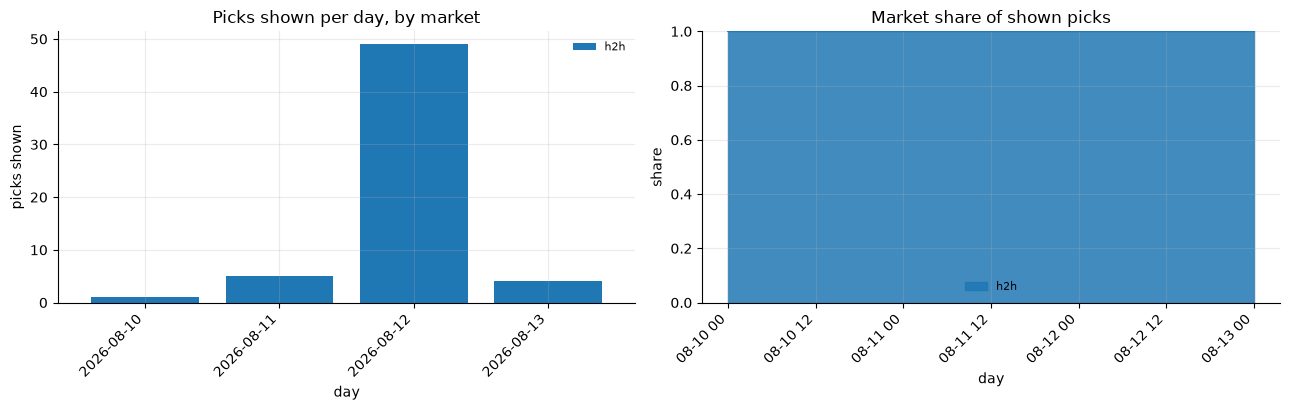

,n,mean_probability,priced
market,,,
h2h,59,0.708,23


In [72]:
if raw_snaps.empty:
    print("no pick snapshots yet")
else:
    snaps = raw_snaps.copy()
    snaps["day"] = pd.to_datetime(snaps["captured_at"], utc=True).dt.date
    mix = snaps.pivot_table(index="day", columns="market", values="id", aggfunc="count").fillna(0)
    share = mix.div(mix.sum(axis=1), axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
    mix.plot(kind="bar", stacked=True, ax=ax1, width=0.8)
    ax1.set_ylabel("picks shown")
    ax1.set_title("Picks shown per day, by market")
    ax1.legend(frameon=False, fontsize=8)
    share.plot(kind="area", stacked=True, ax=ax2, alpha=0.85)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("share")
    ax2.set_title("Market share of shown picks")
    ax2.legend(frameon=False, fontsize=8)
    for a in (ax1, ax2):
        plt.setp(a.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(snaps.groupby("market").agg(
        n=("id", "size"), mean_probability=("probability", "mean"),
        priced=("odds", lambda s: int(s.notna().sum()))).round(3))

## 9. Ad-hoc query

In [87]:
def history(sport=None, league=None, since=None, until=None, market=None,
            tier=None, min_prob=None, correct_only=None, kind=KIND, limit=50):
    """Query the settled CARD-PICK history.

    Returns (rows, summary). The summary is deliberately not optional: a filtered accuracy is the
    easiest number in this project to over-read, and it is usually computed on a handful of rows.

    `market` is a real filter now. It used to print a note saying it was ignored, because graded
    rows were the 1X2 call regardless of what the card showed.
    """
    df = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
    df = df[df["kind"] == kind] if kind else df
    df = df[df["has_card_pick"] & df["graded"].notna()].copy()
    df["correct"] = df["graded"].astype(int)
    if sport:
        df = df[df["sport"] == sport]
    if league:
        df = df[df["league"] == league]
    if market:
        df = df[df["market"] == market]
    if since:
        df = df[df["day"] >= pd.Timestamp(since).date()]
    if until:
        df = df[df["day"] <= pd.Timestamp(until).date()]
    if tier:
        df = df[df["confidence_tier"] == tier]
    if min_prob is not None:
        df = df[df["predicted_prob"] >= min_prob]
    if correct_only is not None:
        df = df[df["correct"] == int(bool(correct_only))]

    summary = summarise(df, "query")
    cols = ["day", "sport", "league", "home_team", "away_team", "market", "predicted",
            "predicted_prob", "odds", "result", "home_score", "away_score",
            "home_corners", "away_corners", "correct", "confidence_tier",
            "feature_completeness", "model_version"]
    return df.sort_values("kickoff_utc", ascending=False)[cols].head(limit), summary


rows, summary = history()
print(summary)
display(rows.head(15))


{'population': 'query', 'n': 147, 'accuracy': 0.6939, 'ci_low': 0.6152, 'ci_high': 0.7627, 'baseline_n': 62, 'baseline': np.float64(0.6391), 'acc_on_baseline_n': np.float64(0.7258), 'gap_pp': np.float64(8.67), 'detectable_pp': 9.45, 'reportable': True, 'conclusive': False}


,day,sport,league,home_team,away_team,market,predicted,predicted_prob,odds,result,home_score,away_score,home_corners,away_corners,correct,confidence_tier,feature_completeness,model_version
49,2026-08-12,tennis,atp,Brandon Nakashima,Rafael Jodar,h2h,HOME,0.561587,3.1500,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
177,2026-08-12,tennis,atp,Titouan Droguet,Stefanos Sakellaridis,h2h,HOME,0.561587,NaN,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
270,2026-08-12,tennis,atp,Dusan Lajovic,Luca Van Assche,h2h,AWAY,0.705128,NaN,AWAY_WIN,1,2,NaN,NaN,1,HIGH,0.928571,tennis_xgb_v20260801195314
271,2026-08-12,tennis,atp,Sho Shimabukuro,J.J. Wolf,h2h,HOME,0.642857,NaN,AWAY_WIN,1,2,NaN,NaN,0,MEDIUM,0.785714,tennis_xgb_v20260801195314
112,2026-08-12,tennis,atp,Michael Zheng,Trevor Svajda,h2h,HOME,0.716216,NaN,HOME_WIN,2,1,NaN,NaN,1,HIGH,0.785714,tennis_xgb_v20260801195314
198,2026-08-12,tennis,atp,Jaime Faria,Yibing Wu,h2h,HOME,0.600000,NaN,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
199,2026-08-12,tennis,atp,Otto Virtanen,Coleman Wong,h2h,AWAY,0.541667,NaN,AWAY_WIN,0,2,NaN,NaN,1,LOW,0.785714,tennis_xgb_v20260801195314
114,2026-08-12,tennis,atp,Quentin Halys,Yunchaokete Bu,h2h,HOME,0.689024,NaN,HOME_WIN,2,0,NaN,NaN,1,HIGH,0.928571,tennis_xgb_v20260801195314
115,2026-08-12,tennis,atp,Marco Trungelliti,Kei Nishikori,h2h,HOME,0.600000,NaN,HOME_WIN,2,1,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
176,2026-08-12,tennis,atp,Nicolai Budkov Kjaer,Kyrian Jacquet,h2h,HOME,0.550000,NaN,AWAY_WIN,0,2,NaN,NaN,0,MEDIUM,0.785714,tennis_xgb_v20260801195314


In [86]:
# Fottball only

def history(sport=None, league=None, since=None, until=None, market=None,
            tier=None, min_prob=None, correct_only=None, kind=KIND, limit=50):
    """Query the settled CARD-PICK history.

    Returns (rows, summary). The summary is deliberately not optional: a filtered accuracy is the
    easiest number in this project to over-read, and it is usually computed on a handful of rows.

    `market` is a real filter now. It used to print a note saying it was ignored, because graded
    rows were the 1X2 call regardless of what the card showed.
    """
    df = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
    df = df[df["kind"] == kind] if kind else df
    df = df[df["has_card_pick"] & df["graded"].notna()].copy()
    df["correct"] = df["graded"].astype(int)
    if sport:
        df = df[df["sport"] == sport]
    if league:
        df = df[df["league"] == league]
    if market:
        df = df[df["market"] == market]
    if since:
        df = df[df["day"] >= pd.Timestamp(since).date()]
    if until:
        df = df[df["day"] <= pd.Timestamp(until).date()]
    if tier:
        df = df[df["confidence_tier"] == tier]
    if min_prob is not None:
        df = df[df["predicted_prob"] >= min_prob]
    if correct_only is not None:
        df = df[df["correct"] == int(bool(correct_only))]

    summary = summarise(df, "query")
    cols = ["day", "sport", "league", "home_team", "away_team", "market", "predicted",
            "predicted_prob", "odds", "result", "home_score", "away_score",
            "home_corners", "away_corners", "correct", "confidence_tier",
            "feature_completeness", "model_version"]
    return df.sort_values("kickoff_utc", ascending=False)[cols].head(limit), summary


rows, summary = history(sport="football")
print(summary)
display(rows.head(15))


{'population': 'query', 'n': 62, 'accuracy': 0.7258, 'ci_low': 0.6041, 'ci_high': 0.8212, 'baseline_n': 62, 'baseline': np.float64(0.6391), 'acc_on_baseline_n': np.float64(0.7258), 'gap_pp': np.float64(8.67), 'detectable_pp': 14.09, 'reportable': False, 'conclusive': False}


,day,sport,league,home_team,away_team,market,predicted,predicted_prob,odds,result,home_score,away_score,home_corners,away_corners,correct,confidence_tier,feature_completeness,model_version
159,2026-08-10,football,allsvenskan,Vasteras SK FK,Djurgardens IF,corners_total,OVER 9.5,0.713837,1.57,HOME_WIN,1,0,4.0,7.0,1,LOW,0.258065,football_xgb_v20260810070503
158,2026-08-10,football,allsvenskan,Sirius,IF Brommapojkarna,corners_total,OVER 9.5,0.712814,1.45,DRAW,2,2,8.0,4.0,1,LOW,0.258065,football_xgb_v20260810070503
39,2026-08-10,football,liga_i,FC Botosani,Corvinul Hunedoara,corners_total,UNDER 10.5,0.673056,1.51,DRAW,0,0,10.0,3.0,0,LOW,0.161290,football_xgb_v20260810070503
153,2026-08-09,football,brasileirao,Flamengo,Vitoria,corners_total,UNDER 10.5,0.659894,1.68,HOME_WIN,2,0,8.0,1.0,1,LOW,0.419355,football_xgb_v20260806213938
147,2026-08-09,football,brasileirao,Santos,Atletico Paranaense,double_chance,1X,0.832161,1.30,AWAY_WIN,0,2,8.0,2.0,0,LOW,0.322581,football_xgb_v20260806213938
150,2026-08-09,football,brasileirao,RB Bragantino,Corinthians,corners_total,OVER 9.5,0.908907,1.87,AWAY_WIN,0,2,3.0,2.0,0,LOW,0.360000,football_xgb_v20260802100216
213,2026-08-09,football,brasileirao,Palmeiras,Internacional,corners_total,UNDER 10.5,0.819144,1.87,DRAW,0,0,5.0,2.0,1,LOW,0.480000,football_xgb_v20260802100216
212,2026-08-09,football,brasileirao,Bahia,Vasco DA Gama,double_chance,1X,0.774202,1.29,DRAW,0,0,4.0,6.0,1,LOW,0.360000,football_xgb_v20260802100216
207,2026-08-09,football,scottish_prem,Rangers,Hibernian,corners_total,UNDER 10.5,0.763720,2.00,AWAY_WIN,1,2,7.0,3.0,1,LOW,0.200000,football_xgb_v20260802100216
205,2026-08-09,football,scottish_prem,Heart Of Midlothian,Dundee Utd,corners_total,UNDER 10.5,0.710492,2.05,HOME_WIN,4,0,7.0,2.0,1,LOW,0.320000,football_xgb_v20260802100216


In [82]:
print(all_graded["sport"].value_counts(dropna=False))

sport
tennis      556
football    184
Name: count, dtype: int64


In [83]:
mask = all_graded["sport"] == "football"
print(all_graded.loc[mask, "market"].value_counts(dropna=False))

market
double_chance    102
corners_total     57
None              19
h2h                6
Name: count, dtype: int64


In [91]:
# Group by league and aggregate the total correct vs incorrect counts

d = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
d = d[d["kind"] == KIND] if KIND else d
d = d[d["has_card_pick"] & d["graded"].notna()].copy()
d["correct"] = d["graded"].astype(int)
d = d[d["sport"] == "football"]

by_league = (
    d.groupby("league")["correct"]
     .agg(correct="sum", n="size")
     .assign(incorrect=lambda x: x["n"] - x["correct"],
             accuracy=lambda x: x["correct"] / x["n"])
     .sort_values("n", ascending=False)
)
print(by_league)

               correct   n  incorrect  accuracy
league                                         
brasileirao         11  16          5    0.6875
mls                 11  16          5    0.6875
csl                 12  15          3    0.8000
scottish_prem        9  12          3    0.7500
allsvenskan          2   2          0    1.0000
liga_i               0   1          1    0.0000


In [88]:
# Tennis Only

# Fottball only

def history(sport=None, league=None, since=None, until=None, market=None,
            tier=None, min_prob=None, correct_only=None, kind=KIND, limit=50):
    """Query the settled CARD-PICK history.

    Returns (rows, summary). The summary is deliberately not optional: a filtered accuracy is the
    easiest number in this project to over-read, and it is usually computed on a handful of rows.

    `market` is a real filter now. It used to print a note saying it was ignored, because graded
    rows were the 1X2 call regardless of what the card showed.
    """
    df = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
    df = df[df["kind"] == kind] if kind else df
    df = df[df["has_card_pick"] & df["graded"].notna()].copy()
    df["correct"] = df["graded"].astype(int)
    if sport:
        df = df[df["sport"] == sport]
    if league:
        df = df[df["league"] == league]
    if market:
        df = df[df["market"] == market]
    if since:
        df = df[df["day"] >= pd.Timestamp(since).date()]
    if until:
        df = df[df["day"] <= pd.Timestamp(until).date()]
    if tier:
        df = df[df["confidence_tier"] == tier]
    if min_prob is not None:
        df = df[df["predicted_prob"] >= min_prob]
    if correct_only is not None:
        df = df[df["correct"] == int(bool(correct_only))]

    summary = summarise(df, "query")
    cols = ["day", "sport", "league", "home_team", "away_team", "market", "predicted",
            "predicted_prob", "odds", "result", "home_score", "away_score",
            "home_corners", "away_corners", "correct", "confidence_tier",
            "feature_completeness", "model_version"]
    return df.sort_values("kickoff_utc", ascending=False)[cols].head(limit), summary


rows, summary = history(sport="tennis")
print(summary)
display(rows.head(15))

{'population': 'query', 'n': 85, 'accuracy': 0.6706, 'ci_low': 0.5652, 'ci_high': 0.7612, 'baseline_n': 0, 'baseline': None, 'acc_on_baseline_n': None, 'gap_pp': None, 'detectable_pp': 12.68, 'reportable': False, 'conclusive': False}


,day,sport,league,home_team,away_team,market,predicted,predicted_prob,odds,result,home_score,away_score,home_corners,away_corners,correct,confidence_tier,feature_completeness,model_version
49,2026-08-12,tennis,atp,Brandon Nakashima,Rafael Jodar,h2h,HOME,0.561587,3.1500,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
177,2026-08-12,tennis,atp,Titouan Droguet,Stefanos Sakellaridis,h2h,HOME,0.561587,NaN,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
270,2026-08-12,tennis,atp,Dusan Lajovic,Luca Van Assche,h2h,AWAY,0.705128,NaN,AWAY_WIN,1,2,NaN,NaN,1,HIGH,0.928571,tennis_xgb_v20260801195314
271,2026-08-12,tennis,atp,Sho Shimabukuro,J.J. Wolf,h2h,HOME,0.642857,NaN,AWAY_WIN,1,2,NaN,NaN,0,MEDIUM,0.785714,tennis_xgb_v20260801195314
112,2026-08-12,tennis,atp,Michael Zheng,Trevor Svajda,h2h,HOME,0.716216,NaN,HOME_WIN,2,1,NaN,NaN,1,HIGH,0.785714,tennis_xgb_v20260801195314
198,2026-08-12,tennis,atp,Jaime Faria,Yibing Wu,h2h,HOME,0.600000,NaN,HOME_WIN,2,0,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
199,2026-08-12,tennis,atp,Otto Virtanen,Coleman Wong,h2h,AWAY,0.541667,NaN,AWAY_WIN,0,2,NaN,NaN,1,LOW,0.785714,tennis_xgb_v20260801195314
114,2026-08-12,tennis,atp,Quentin Halys,Yunchaokete Bu,h2h,HOME,0.689024,NaN,HOME_WIN,2,0,NaN,NaN,1,HIGH,0.928571,tennis_xgb_v20260801195314
115,2026-08-12,tennis,atp,Marco Trungelliti,Kei Nishikori,h2h,HOME,0.600000,NaN,HOME_WIN,2,1,NaN,NaN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
176,2026-08-12,tennis,atp,Nicolai Budkov Kjaer,Kyrian Jacquet,h2h,HOME,0.550000,NaN,AWAY_WIN,0,2,NaN,NaN,0,MEDIUM,0.785714,tennis_xgb_v20260801195314


In [89]:
mask = all_graded["sport"] == "tennis"
print(all_graded.loc[mask, "market"].value_counts(dropna=False))

market
h2h    556
Name: count, dtype: int64


In [90]:
# Checking tennis total correct vs incorrect counts

d = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
d = d[d["kind"] == KIND] if KIND else d
d = d[d["has_card_pick"] & d["graded"].notna()].copy()
d["correct"] = d["graded"].astype(int)
d = d[d["sport"] == "tennis"]

by_league = (
    d.groupby("league")["correct"]
     .agg(correct="sum", n="size")
     .assign(incorrect=lambda x: x["n"] - x["correct"],
             accuracy=lambda x: x["correct"] / x["n"])
     .sort_values("n", ascending=False)
)
print(by_league)

        correct   n  incorrect  accuracy
league                                  
atp          57  85         28  0.670588


In [79]:
# Examples - edit freely. Every one of these is a CARD-pick accuracy, not a 1X2 one.
for label, kwargs in [
    ("football, high confidence", dict(sport="football", tier="HIGH")),
    ("football, corners only", dict(sport="football", market="corners_total")),
    ("football, h2h only", dict(sport="football", market="h2h")),
    ("tennis, model gave >=70%", dict(sport="tennis", min_prob=0.70)),
    ("last 3 days, all sports", dict(since=(pd.Timestamp.utcnow() - pd.Timedelta(days=3)).date())),
]:
    _, s = history(**kwargs)
    if not s["n"]:
        print(f"{label:<28} no rows")
        continue
    # baseline is None wherever the sport has no measured base rate - tennis abstains by
    # design, so it is reported blank rather than compared against a borrowed football number.
    base = (f"vs base {s['baseline']:.3f} ({s['gap_pp']:+.1f}pp)"
            if s["baseline"] is not None else "no measured base rate for this sport")
    print(f"{label:<28} n={s['n']:<4} acc={s['accuracy']:.3f} "
          f"CI[{s['ci_low']:.2f},{s['ci_high']:.2f}] {base}, "
          f"detectable {s['detectable_pp']:.1f}pp")


football, high confidence    n=4    acc=1.000 CI[0.51,1.00] vs base 0.712 (+28.8pp), detectable 0.0pp
football, corners only       n=19   acc=0.737 CI[0.51,0.88] vs base 0.545 (+19.1pp), detectable 25.1pp
football, h2h only           no rows
tennis, model gave >=70%     n=24   acc=0.625 CI[0.43,0.79] no measured base rate for this sport, detectable 24.6pp
last 3 days, all sports      n=17   acc=0.706 CI[0.47,0.87] vs base 0.554 (+11.3pp), detectable 27.5pp


## 10. Retrodictions — inspect, never headline

A retrodiction is generated after the result is known. It belongs in the feed so a past card can
show what the model would have called, and it must never appear in a skill number. It is shown
here on its own so the difference is visible rather than assumed — retrodictions historically
score *worse*, because `assemble_from_game_log` carries a leakage guard and thinner features.

In [75]:
retro = all_graded[(all_graded["kind"] == "RETRODICTION") & (all_graded["result_type"].isna())]
pre = all_graded[(all_graded["kind"] == "PRE_MATCH") & (all_graded["result_type"].isna())]
unknown = all_graded[all_graded["kind"] == "UNKNOWN"]

comp = pd.DataFrame([
    summarise(gradeable(pre), "PRE_MATCH (the only skill evidence)"),
    summarise(gradeable(retro), "RETRODICTION (inspection only)"),
    summarise(gradeable(unknown), "UNKNOWN provenance (excluded)"),
])
display(comp)
print("Mixing these was a real defect: /history/summary once averaged pre-match and retrodicted "
      "rows into one live, user-facing accuracy. Keeping them apart is the point of predictions.kind.")

,population,n,accuracy,ci_low,ci_high,baseline_n,baseline,acc_on_baseline_n,gap_pp,detectable_pp,reportable,conclusive
0,PRE_MATCH (the only skill evidence),147,0.6939,0.6152,0.7627,62.0,0.6391,0.7258,8.67,9.45,True,False
1,RETRODICTION (inspection only),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UNKNOWN provenance (excluded),564,0.6206,0.5798,0.6597,103.0,0.5926,0.6699,7.73,5.08,True,False


Mixing these was a real defect: /history/summary once averaged pre-match and retrodicted rows into one live, user-facing accuracy. Keeping them apart is the point of predictions.kind.
